# DeepWeeds — Lab Day 2 (Kaggle + GPU)

Notebook này hoàn thiện bộ khung `starter/` và tổ chức thí nghiệm theo đúng quy tắc fold 0.

**Quan trọng:** dataset không nằm trong repo bài nộp. Hãy đặt ảnh/CSV trên Kaggle Input (dataset được Add Input trực tiếp). Chọn cấu hình/siêu tham số bằng **validation**; chỉ chạy **test một lần/seed** cho final và baseline ở cuối.


In [1]:
# 0. Cài môi trường
!pip -q install timm==1.0.30 fvcore thop openpyxl scikit-learn

import os, sys, json, time, shutil, glob, math
from pathlib import Path
import numpy as np, pandas as pd
import torch

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

# /kaggle/input: chỉ đọc
# /kaggle/working: nơi lưu checkpoint, predictions, results

LAB_DIR = "/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab"

WORK_DIR = "/kaggle/working/DeepWeeds_Lab"

RUNS_DIR = f"{WORK_DIR}/runs"
PRED_DIR = f"{WORK_DIR}/predictions"
EVAL_DIR = f"{WORK_DIR}/eval"

os.makedirs(RUNS_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)
os.makedirs(EVAL_DIR, exist_ok=True)

print("LAB_DIR:", LAB_DIR)
print("WORK_DIR:", WORK_DIR)
print("Output directories ready.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 35.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 6.7 MB/s eta 0:00:00
Torch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4
CUDA version: 12.8
LAB_DIR: /kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab
WORK_DIR: /kaggle/working/DeepWeeds_Lab
Output directories ready.


In [2]:
# 1. Kaggle Input paths
# Dataset DeepWeeds được Add Input trực tiếp từ Kaggle.
# Bộ lab/code được Add Input riêng. Không cần mount Drive.

IMAGES_DIR = "/kaggle/input/datasets/imsparsh/deepweeds/images"
LABELS_DIR = "/kaggle/input/datasets/imsparsh/deepweeds/labels"
REPO_DIR = "/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab"

print("IMAGES_DIR:", IMAGES_DIR, os.path.exists(IMAGES_DIR))
print("LABELS_DIR:", LABELS_DIR, os.path.exists(LABELS_DIR))
print("REPO_DIR:", REPO_DIR, os.path.exists(REPO_DIR))

assert os.path.isdir(IMAGES_DIR), f"Missing images directory: {IMAGES_DIR}"
assert os.path.isdir(LABELS_DIR), f"Missing labels directory: {LABELS_DIR}"
assert os.path.isdir(REPO_DIR), f"Missing lab directory: {REPO_DIR}"


IMAGES_DIR: /kaggle/input/datasets/imsparsh/deepweeds/images True
LABELS_DIR: /kaggle/input/datasets/imsparsh/deepweeds/labels True
REPO_DIR: /kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab True


## Nếu thiếu labels

Trong cấu hình Kaggle này, dataset `DeepWeeds` đã được Add Input trực tiếp và thư mục `labels/` đã có sẵn. Vì vậy **không cần tải hoặc unzip labels** trong notebook này.

Không sửa các CSV fold 0; notebook sẽ dùng `load_split(LABELS_DIR, fold=0)` và chỉ chọn cấu hình bằng validation.


In [3]:
# 1b. Không cần tải/unzip dataset trên Kaggle
# Dataset đã nằm trong /kaggle/input/deepweeds và là read-only.
# Nếu cell kiểm tra ở trên in True cho IMAGES_DIR/LABELS_DIR thì bỏ qua cell này.


In [4]:
# 2. Load code lab từ Kaggle Input
# Không copy code; /kaggle/input đã chứa sẵn code của lab.
SOURCE_CODE_DIR = f"{REPO_DIR}/code"

sys.path.insert(0, SOURCE_CODE_DIR)
sys.path.insert(0, REPO_DIR)

from dataset import *
from model import *
from losses import *
from train import Config, run
import inference, benchmark

print("Code loaded.")
print("SOURCE_CODE_DIR:", SOURCE_CODE_DIR)


Code loaded.
SOURCE_CODE_DIR: /kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code


In [5]:
# 3. Load split — tương thích với dataset DeepWeeds trên Kaggle

from pathlib import Path
import pandas as pd

def load_split(labels_dir, fold=0):
    labels_dir = Path(labels_dir)

    # Các split của Kaggle
    paths = {
        "train": labels_dir / f"train_subset{fold}.csv",
        "val":   labels_dir / f"val_subset{fold}.csv",
        "test":  labels_dir / f"test_subset{fold}.csv",
    }

    # Bảng đầy đủ có Species
    master = pd.read_csv(labels_dir / "labels.csv")

    required_master = {"Filename", "Label", "Species"}
    if not required_master.issubset(master.columns):
        raise ValueError(
            f"labels.csv thiếu cột: {required_master - set(master.columns)}"
        )

    # Tạo mapping Filename -> Species
    species_map = master.set_index("Filename")["Species"]

    dfs = []

    for name, path in paths.items():
        if not path.exists():
            raise FileNotFoundError(f"Missing CSV: {path}")

        df = pd.read_csv(path)

        # Kiểm tra split
        if not {"Filename", "Label"}.issubset(df.columns):
            raise ValueError(
                f"{name} thiếu cột Filename/Label"
            )

        if df["Filename"].duplicated().any():
            raise ValueError(f"{name} có Filename trùng")

        # Lấy Species từ labels.csv
        df["Species"] = df["Filename"].map(species_map)

        # Kiểm tra filename có trong labels.csv
        if df["Species"].isna().any():
            missing = df.loc[df["Species"].isna(), "Filename"].tolist()
            raise ValueError(
                f"{name} có {len(missing)} ảnh không tìm thấy trong labels.csv"
            )

        # Kiểm tra label
        if not df["Label"].between(0, 8).all():
            raise ValueError(f"{name} có Label ngoài 0..8")

        dfs.append(df)

    return tuple(dfs)


# Load fold 0
train_df, val_df, test_df = load_split(LABELS_DIR, fold=0)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

print("\nColumns:")
print(train_df.columns.tolist())

print("\nSample:")
display(train_df.head())

Train: 10501
Val:   3501
Test:  3507

Columns:
['Filename', 'Label', 'Species']

Sample:


,Filename,Label,Species
0,20171109-175921-2.jpg,5,Rubber vine
1,20170714-142019-3.jpg,1,Lantana
2,20170718-101402-2.jpg,0,Chinee apple
3,20170126-095456-0.jpg,1,Lantana
4,20170913-110647-1.jpg,3,Parthenium


In [6]:
split_info = check_split(
    train_df,
    val_df,
    test_df,
    IMAGES_DIR
)

display(pd.DataFrame(split_info["per_class"]).T)

Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
Overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Union: 17509
       Chinee Apple  Lantana  Parkinsonia  Parthenium  Prickly Acacia  \
train           675      637          618         613             637   
val             225      213          206         204             212   
test            226      213          207         205             213   

       Rubber Vine  Siam Weed  Snake Weed  Negatives  
train          605        644         609       5463  
val            202        215         203       1821  
test           202        215         204       1822  


,Chinee Apple,Lantana,Parkinsonia,Parthenium,Prickly Acacia,Rubber Vine,Siam Weed,Snake Weed,Negatives
train,675,637,618,613,637,605,644,609,5463
val,225,213,206,204,212,202,215,203,1821
test,226,213,207,205,213,202,215,204,1822


In [7]:
# Patch train.py để dùng load_split đã sửa
import train

train.load_split = load_split

print("Patched train.load_split:", train.load_split is load_split)

Patched train.load_split: True


Class distribution:


,train,val,test
Chinee Apple,675,225,226
Lantana,637,213,213
Parkinsonia,618,206,207
Parthenium,613,204,205
Prickly Acacia,637,212,213
Rubber Vine,605,202,202
Siam Weed,644,215,215
Snake Weed,609,203,204
Negatives,5463,1821,1822


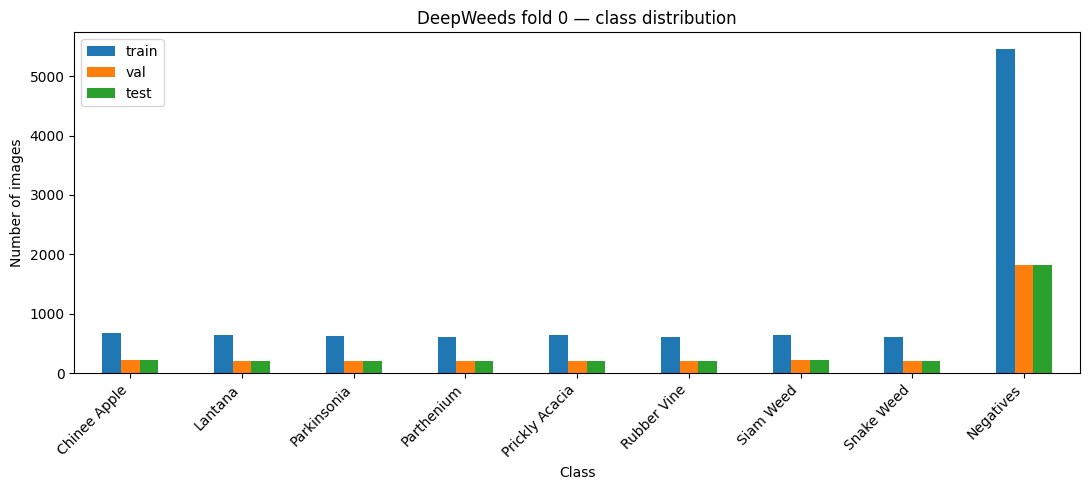

Saved: /kaggle/working/DeepWeeds_Lab/eda_class_distribution.png
Imbalance ratio train max/min (weed classes): 1.115702479338843
Negative / smallest weed class: 9.029752066115703


In [8]:
# 4. EDA: phân bố lớp
import matplotlib.pyplot as plt
import pandas as pd
import os

os.makedirs(WORK_DIR, exist_ok=True)

eda = pd.DataFrame({
    "train": train_df["Label"].value_counts()
                     .reindex(range(9), fill_value=0)
                     .to_numpy(),

    "val": val_df["Label"].value_counts()
                 .reindex(range(9), fill_value=0)
                 .to_numpy(),

    "test": test_df["Label"].value_counts()
                   .reindex(range(9), fill_value=0)
                   .to_numpy(),
}, index=CLASS_NAMES)

print("Class distribution:")
display(eda)

fig, ax = plt.subplots(figsize=(11, 5))

eda.plot(kind="bar", ax=ax)

ax.set_title("DeepWeeds fold 0 — class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

save_path = f"{WORK_DIR}/eda_class_distribution.png"
plt.savefig(save_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

weed_counts = eda["train"].iloc[:8]

print(
    "Imbalance ratio train max/min (weed classes):",
    weed_counts.max() / weed_counts.min()
)

print(
    "Negative / smallest weed class:",
    eda.loc["Negatives", "train"] / weed_counts.min()
)

In [9]:
# 4b. Lưới ảnh mẫu mỗi lớp (3 ảnh/lớp)
import matplotlib.pyplot as plt
from PIL import Image
_lab = "Label" if "Label" in train_df.columns else train_df.columns[1]
fig, axs = plt.subplots(9, 3, figsize=(7.5, 22))
for c in range(9):
    sample = train_df[train_df[_lab] == c].sample(3, random_state=0)
    for j, fn in enumerate(sample.Filename):
        axs[c, j].imshow(Image.open(f"{IMAGES_DIR}/{fn}").convert("RGB")); axs[c, j].axis("off")
        if j == 0: axs[c, j].set_title(CLASS_NAMES[c], fontsize=9, loc="left")
plt.tight_layout(); plt.savefig(f"{WORK_DIR}/eda_samples_per_class.png", dpi=110); plt.show()

[Ảnh đã lược khỏi notebook để giảm dung lượng; xem figures/eda_samples_per_class.png]


In [10]:
# 5. Kiểm tra pipeline augmentation + batch
tr_loader = make_loader(
    train_df, IMAGES_DIR,
    build_transforms(True, 224, "basic"),
    batch_size=16, train=True, sampler=None, num_workers=2
)
fig = preview_batch(tr_loader, n=9)
plt.show()


[Ảnh đã lược khỏi notebook để giảm dung lượng; xem figures/augmentation_preview.png]


In [11]:
# 6. Sanity check loss ban đầu và focal gamma=0
import torch.nn.functional as F
from losses import FocalLoss

print("Expected CE for 9 classes:", -math.log(1/9))
z = torch.zeros(32, 9)
y = torch.randint(0, 9, (32,))
print("CE(uniform logits):", float(F.cross_entropy(z, y)))
print("Focal gamma=0:", self_check_focal())


Expected CE for 9 classes: 2.1972245773362196
CE(uniform logits): 2.1972243785858154
Focal gamma=0: (2.646662473678589, 2.646662473678589)


In [12]:
# 6b. Overfit một batch nhỏ (rubric A). KHÔNG đưa kết quả này vào bảng thí nghiệm.
# Kỳ vọng: loss đầu ~ ln 9 = 2.197, loss giảm gần 0, acc batch -> 1.0 sau vài chục step.
import torch, math, numpy as np
from dataset import make_loader, build_transforms
from model import build_model
from losses import build_criterion

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
_loader = make_loader(train_df, IMAGES_DIR, build_transforms(False, 224, "basic"),
                      batch_size=16, train=False, sampler=None, num_workers=2)
xb, yb, _ = next(iter(_loader)); xb, yb = xb.to(dev), yb.to(dev)
print("nhãn trong batch:", yb.tolist())
_m = build_model("convnext_tiny", pretrained=True, num_classes=9, init="finetune").to(dev).train()
_opt = torch.optim.AdamW(_m.parameters(), lr=1e-4, weight_decay=0.0)
_crit = build_criterion("ce"); _log = []
for step in range(60):
    _opt.zero_grad(set_to_none=True)
    loss = _crit(_m(xb), yb); loss.backward(); _opt.step()
    if step % 10 == 0 or step == 59:
        with torch.no_grad(): acc = (_m(xb).argmax(1) == yb).float().mean().item()
        _log.append((step, loss.item(), acc)); print(f"step {step:02d} loss={loss.item():.4f} acc={acc:.2f}")
print(f"loss đầu = {_log[0][1]:.3f} (ln9 = {math.log(9):.3f}); loss cuối = {_log[-1][1]:.4f}")
del _m, _opt; torch.cuda.empty_cache()

nhãn trong batch: [5, 1, 0, 1, 3, 8, 5, 1, 6, 8, 8, 8, 8, 8, 8, 8]


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

step 00 loss=2.3511 acc=0.50
step 10 loss=0.0060 acc=1.00
step 20 loss=0.0009 acc=1.00
step 30 loss=0.0002 acc=1.00
step 40 loss=0.0001 acc=1.00
step 50 loss=0.0001 acc=1.00
step 59 loss=0.0001 acc=1.00
loss đầu = 2.351 (ln9 = 2.197); loss cuối = 0.0001


In [13]:
# 7. Danh sách backbone bắt buộc
BACKBONES = {
    "B01": "resnet50",
    "B02": "resnext50_32x4d",
    "B03": "convnext_tiny",
    "B04": "deit_small_patch16_224",
    "B05": "efficientnet_b0",
    # Có thể thêm:
    # "B06": "swin_tiny_patch4_window7_224",
    # "B07": "mobilenetv3_large_100",
}
for exp, name in BACKBONES.items():
    print(exp, name)


B01 resnet50
B02 resnext50_32x4d
B03 convnext_tiny
B04 deit_small_patch16_224
B05 efficientnet_b0


In [14]:
# 7b. Ghi version thư viện và tag trọng số timm
import timm, torchvision, sklearn, platform, json
print("python", platform.python_version(), "| torch", torch.__version__, "| torchvision", torchvision.__version__,
      "| timm", timm.__version__, "| sklearn", sklearn.__version__)
_tags = {}
for exp, name in BACKBONES.items():
    _mm = timm.create_model(name, pretrained=False)          # chỉ đọc cấu hình, không tải trọng số
    cfg_ = _mm.pretrained_cfg
    _tags[exp] = dict(backbone=name, tag=cfg_.get("tag"), hf_hub_id=cfg_.get("hf_hub_id"))
    print(exp, _tags[exp]); del _mm
json.dump(_tags, open(f"{WORK_DIR}/weights_tags.json", "w"), indent=1)

python 3.13.15 | torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | timm 1.0.30 | sklearn 1.6.1
B01 {'backbone': 'resnet50', 'tag': 'a1_in1k', 'hf_hub_id': 'timm/resnet50.a1_in1k'}
B02 {'backbone': 'resnext50_32x4d', 'tag': 'a1h_in1k', 'hf_hub_id': 'timm/resnext50_32x4d.a1h_in1k'}
B03 {'backbone': 'convnext_tiny', 'tag': 'in12k_ft_in1k', 'hf_hub_id': 'timm/convnext_tiny.in12k_ft_in1k'}
B04 {'backbone': 'deit_small_patch16_224', 'tag': 'fb_in1k', 'hf_hub_id': 'timm/deit_small_patch16_224.fb_in1k'}
B05 {'backbone': 'efficientnet_b0', 'tag': 'ra_in1k', 'hf_hub_id': 'timm/efficientnet_b0.ra_in1k'}


## Bước 1 — Backbone sweep

Công thức nền: ImageNet pretrained + finetune, 224px, basic augmentation, CE, AdamW, LR backbone/head = 1e-4/1e-3, WD=0.05, warmup+cosine, AMP.

Chạy cùng seed cho mọi backbone. Nếu Colab hết thời gian, giảm số backbone/epoch **nhưng ghi rõ trong report**.


In [15]:
# 8. Chạy backbone sweep
# Để tránh vô tình chạy hàng giờ, mặc định RUN=False.
RUN_BACKBONES = True
BACKBONE_EPOCHS = 12
BACKBONE_SEED = 0

backbone_results = []
if RUN_BACKBONES:
    for exp_id, backbone in BACKBONES.items():
        cfg = Config(
            exp_id=exp_id, seed=BACKBONE_SEED, backbone=backbone,
            epochs=BACKBONE_EPOCHS, batch_size=64,
            images_dir=IMAGES_DIR, labels_dir=LABELS_DIR,
            out_dir=RUNS_DIR,
            pred_dir=PRED_DIR,
            save_test_predictions=False
        )
        r=run(cfg); backbone_results.append(r)
        print(r)
pd.DataFrame(backbone_results)


Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
Overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Union: 17509
       Chinee Apple  Lantana  Parkinsonia  Parthenium  Prickly Acacia  \
train           675      637          618         613             637   
val             225      213          206         204             212   
test            226      213          207         205             213   

       Rubber Vine  Siam Weed  Snake Weed  Negatives  
train          605        644         609       5463  
val            202        215         203       1821  
test           202        215         204       1822  


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:147: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=GradScaler(enabled=(cfg.amp and device.type=="cuda"))
/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:91: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(cfg.amp and device.type=="cuda")):
/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:107: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type=="cuda")): z=model(x)


epoch 01/12 loss=1.6323 valF1=0.2345 valAcc=0.5704
epoch 02/12 loss=0.8961 valF1=0.6268 valAcc=0.7469
epoch 03/12 loss=0.5980 valF1=0.7196 valAcc=0.8023
epoch 04/12 loss=0.4582 valF1=0.7314 valAcc=0.8109
epoch 05/12 loss=0.3773 valF1=0.7722 valAcc=0.8389
epoch 06/12 loss=0.3315 valF1=0.7869 valAcc=0.8483
epoch 07/12 loss=0.3017 valF1=0.7980 valAcc=0.8546
epoch 08/12 loss=0.2698 valF1=0.7957 valAcc=0.8532
epoch 09/12 loss=0.2523 valF1=0.8057 valAcc=0.8592
epoch 10/12 loss=0.2437 valF1=0.8139 valAcc=0.8652
epoch 11/12 loss=0.2467 valF1=0.8062 valAcc=0.8592
epoch 12/12 loss=0.2402 valF1=0.8092 valAcc=0.8615


...

/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:147: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=GradScaler(enabled=(cfg.amp and device.type=="cuda"))
/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:91: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(cfg.amp and device.type=="cuda")):
/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:97: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#

epoch 01/12 loss=1.9836 valF1=0.5069 valAcc=0.6064
epoch 02/12 loss=0.6026 valF1=0.6700 valAcc=0.7612
epoch 03/12 loss=0.3199 valF1=0.7443 valAcc=0.8101
epoch 04/12 loss=0.2083 valF1=0.8062 valAcc=0.8558
epoch 05/12 loss=0.1351 valF1=0.8052 valAcc=0.8578
epoch 06/12 loss=0.0918 valF1=0.8191 valAcc=0.8686
epoch 07/12 loss=0.0722 valF1=0.8409 valAcc=0.8812
epoch 08/12 loss=0.0607 valF1=0.8432 valAcc=0.8823
epoch 09/12 loss=0.0452 valF1=0.8545 valAcc=0.8935
epoch 10/12 loss=0.0412 valF1=0.8584 valAcc=0.8960
epoch 11/12 loss=0.0390 valF1=0.8483 valAcc=0.8886
epoch 12/12 loss=0.0331 valF1=0.8548 valAcc=0.8926


Unsupported operator aten::silu_ encountered 49 time(s)
Unsupported operator aten::mean encountered 16 time(s)
Unsupported operator aten::sigmoid encountered 16 time(s)
Unsupported operator aten::mul encountered 16 time(s)
Unsupported operator aten::add encountered 9 time(s)


{'exp_id': 'B05', 'seed': 0, 'best_epoch': 10, 'macro_f1_val': 0.8584108301155069, 'top1_val': 0.8960297057983433, 'params_m': 4.019077, 'gmac': 0.398084384, 'train_sec': 427.4064133167267, 'device': 'cuda'}


,exp_id,seed,best_epoch,macro_f1_val,top1_val,params_m,gmac,train_sec,device
0,B01,0,10,0.813939,0.865181,23.526473,4.109483,886.271657,cuda
1,B02,0,11,0.861159,0.896315,22.998345,4.257352,776.581117,cuda
2,B03,0,11,0.967176,0.975150,27.827049,4.469676,693.833412,cuda
3,B04,0,11,0.952913,0.965438,21.669129,4.250294,487.094715,cuda
4,B05,0,10,0.858411,0.896030,4.019077,0.398084,427.406413,cuda


## Bước 2 — Training ablation

Dưới đây là một thiết kế tối thiểu có **3 trục**, mỗi trục ≥2 giá trị:
- A: initialization — scratch / frozen / finetune
- B: augmentation — basic / color / randaug
- C: loss — CE / label smoothing / focal

Mỗi lần chỉ thay một yếu tố so với baseline `T00`. Sau khi có số liệu val, có thể chọn cấu hình tốt để làm **một combination** (ví dụ CutMix + LS + EMA).


In [16]:
# 9. Training experiments — mặc định không chạy
ABLATIONS = [
    ("T00", dict(init="finetune", aug="basic", loss="ce")),
    ("T01", dict(init="scratch",  aug="basic", loss="ce")),       # A
    ("T02", dict(init="frozen",   aug="basic", loss="ce")),       # A
    ("T03", dict(init="finetune", aug="color", loss="ce")),       # B
    ("T04", dict(init="finetune", aug="randaug", loss="ce")),     # B
    ("T05", dict(init="finetune", aug="basic", loss="ls",
                 label_smoothing=0.1)),                           # C
    ("T06", dict(init="finetune", aug="basic", loss="focal",
                 focal_gamma=2.0)),                              # C
    # Combination candidate — chỉ chạy sau khi chọn được các yếu tố tốt trên val:
    # ("T07", dict(aug="color", loss="ls", label_smoothing=0.1,
    #              mix="cutmix", mix_alpha=1.0, ema_decay=0.999)),
]
ABLATION_BACKBONE = "convnext_tiny"  # thay bằng backbone được chọn từ Bước 1
RUN_ABLATIONS = True

ablation_results=[]
if RUN_ABLATIONS:
    for exp_id, kw in ABLATIONS:
        cfg=Config(exp_id=exp_id, seed=0, backbone=ABLATION_BACKBONE,
                   epochs=12,batch_size=64,images_dir=IMAGES_DIR,labels_dir=LABELS_DIR,
                   out_dir=RUNS_DIR,
                   pred_dir=PRED_DIR,
                   **kw)
        ablation_results.append(run(cfg))
pd.DataFrame(ablation_results)


Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
Overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Union: 17509
       Chinee Apple  Lantana  Parkinsonia  Parthenium  Prickly Acacia  \
train           675      637          618         613             637   
val             225      213          206         204             212   
test            226      213          207         205             213   

       Rubber Vine  Siam Weed  Snake Weed  Negatives  
train          605        644         609       5463  
val            202        215         203       1821  
test           202        215         204       1822  


/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:147: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=GradScaler(enabled=(cfg.amp and device.type=="cuda"))
/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:91: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(cfg.amp and device.type=="cuda")):
/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:97: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#

epoch 01/12 loss=0.6609 valF1=0.8551 valAcc=0.8852
epoch 02/12 loss=0.2669 valF1=0.9049 valAcc=0.9263
epoch 03/12 loss=0.1829 valF1=0.9186 valAcc=0.9386
epoch 04/12 loss=0.1325 valF1=0.9089 valAcc=0.9243
epoch 05/12 loss=0.0971 valF1=0.9445 valAcc=0.9577
epoch 06/12 loss=0.0543 valF1=0.9402 valAcc=0.9569
epoch 07/12 loss=0.0341 valF1=0.9420 valAcc=0.9557
epoch 08/12 loss=0.0208 valF1=0.9607 valAcc=0.9697
epoch 09/12 loss=0.0063 valF1=0.9596 valAcc=0.9692
epoch 10/12 loss=0.0023 valF1=0.9645 valAcc=0.9740
epoch 11/12 loss=0.0006 valF1=0.9672 valAcc=0.9751
epoch 12/12 loss=0.0005 valF1=0.9672 valAcc=0.9751


Unsupported operator aten::gelu encountered 18 time(s)
Unsupported operator aten::mul encountered 18 time(s)
Unsupported operator aten::add encountered 18 time(s)


Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
Overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Union: 17509
       Chinee Apple  Lantana  Parkinsonia  Parthenium  Prickly Acacia  \
train           675      637          618         613             637   
val             225      213          206         204             212   
test            226      213          207         205             213   

       Rubber Vine  Siam Weed  Snake Weed  Negatives  
train          605        644         609       5463  
val            202        215         203       1821  
test           202        215         204       1822  


...

Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
Overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Union: 17509
       Chinee Apple  Lantana  Parkinsonia  Parthenium  Prickly Acacia  \
train           675      637          618         613             637   
val             225      213          206         204             212   
test            226      213          207         205             213   

       Rubber Vine  Siam Weed  Snake Weed  Negatives  
train          605        644         609       5463  
val            202        215         203       1821  
test           202        215         204       1822  


/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:147: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=GradScaler(enabled=(cfg.amp and device.type=="cuda"))
/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:91: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(cfg.amp and device.type=="cuda")):
/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:97: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#

epoch 01/12 loss=0.4284 valF1=0.8630 valAcc=0.8915
epoch 02/12 loss=0.1359 valF1=0.8847 valAcc=0.9112
epoch 03/12 loss=0.0862 valF1=0.9192 valAcc=0.9297
epoch 04/12 loss=0.0594 valF1=0.9059 valAcc=0.9235
epoch 05/12 loss=0.0390 valF1=0.9291 valAcc=0.9446
epoch 06/12 loss=0.0234 valF1=0.9428 valAcc=0.9560
epoch 07/12 loss=0.0120 valF1=0.9494 valAcc=0.9606
epoch 08/12 loss=0.0048 valF1=0.9570 valAcc=0.9672
epoch 09/12 loss=0.0012 valF1=0.9618 valAcc=0.9697
epoch 10/12 loss=0.0012 valF1=0.9626 valAcc=0.9714
epoch 11/12 loss=0.0003 valF1=0.9661 valAcc=0.9743
epoch 12/12 loss=0.0002 valF1=0.9668 valAcc=0.9746


Unsupported operator aten::gelu encountered 18 time(s)
Unsupported operator aten::mul encountered 18 time(s)
Unsupported operator aten::add encountered 18 time(s)


,exp_id,seed,best_epoch,macro_f1_val,top1_val,params_m,gmac,train_sec,device
0,T00,0,11,0.967176,0.975150,27.827049,4.469676,678.128499,cuda
1,T01,0,7,0.313097,0.566410,27.827049,4.469676,695.271248,cuda
2,T02,0,9,0.855412,0.884890,27.827049,4.469676,403.328995,cuda
3,T03,0,11,0.964376,0.971722,27.827049,4.469676,770.762681,cuda
4,T04,0,12,0.965910,0.972865,27.827049,4.469676,682.590367,cuda
5,T05,0,8,0.966434,0.973436,27.827049,4.469676,689.473814,cuda
6,T06,0,12,0.966771,0.974579,27.827049,4.469676,673.146723,cuda


## Bước 3 — Inference

Các phép dưới đây phải được chọn trên **val**:
1. 1-view baseline
2. Hflip TTA
3. 5-crop / multi-scale
4. probability-vs-logit aggregation
5. temperature scaling
6. ensemble
7. FP16/AMP hoặc BN fusion

TTA/độ phân giải cần forward lại model; các phép gộp/calibration có thể làm trên logits đã lưu.


In [17]:
# 10. Load một checkpoint tốt nhất và benchmark latency
# CHỈ chạy sau khi đã có một run.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model("convnext_tiny", pretrained=True, num_classes=9, init="finetune").to(DEVICE)
# F01 seed0 tái lập đúng T00 ConvNeXt seed0; dùng T00 nếu F01 chưa được train (chạy tuần tự từ trên xuống)
_exp = "F01" if os.path.exists(f"{RUNS_DIR}/F01/seed0/best.pt") else "T00"
ckpt = torch.load(f"{RUNS_DIR}/{_exp}/seed0/best.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model"]); model.eval()
print(benchmark.latency_report(model, batch_size=1, img_size=224, dtype="fp32", device=str(DEVICE), warmup=10, iters=100))
print(benchmark.latency_report(model, batch_size=1, img_size=224, dtype="amp", device=str(DEVICE), warmup=10, iters=100))


{'p50': 5.815374001031159, 'p95': 6.379306900817028, 'p99': 6.545345920985711, 'mean': 5.88211811011206, 'n': 100, 'gpu': 'Tesla T4', 'dtype': 'fp32', 'batch': 1, 'img_size': 224, 'images_per_s': 171.95798581874251, 'torch': '2.11.0+cu128'}
{'p50': 7.494850000512088, 'p95': 7.93730229997891, 'p99': 8.711790229954206, 'mean': 7.567249739986437, 'n': 100, 'gpu': 'Tesla T4', 'dtype': 'amp', 'batch': 1, 'img_size': 224, 'images_per_s': 133.42495179111987, 'torch': '2.11.0+cu128'}


In [18]:
# 11. Temperature scaling từ logits VAL — không dùng TEST để fit T
_exp = "F01" if os.path.exists(f"{RUNS_DIR}/F01/seed0/val_logits.npy") else "T00"
val_logits = np.load(f"{RUNS_DIR}/{_exp}/seed0/val_logits.npy")
val_y = np.load(f"{RUNS_DIR}/{_exp}/seed0/val_y.npy")
T = inference.fit_temperature(val_logits, val_y)
p_uncal = torch.softmax(torch.from_numpy(val_logits),1).numpy()
p_cal = inference.apply_temperature(val_logits, T)
print("Temperature:", T)


Temperature: 2.011909246444702


## Bước 4 — Final ≥3 seed

Sau khi **chốt toàn bộ cấu hình chỉ bằng val**, chạy:
- `T00` baseline với seed 0,1,2
- `F01` final với seed 0,1,2

`save_test_predictions=True` chỉ bật ở đây. Mỗi seed tạo đúng một file test. Sau khi đã mở test, không quay lại chọn cấu hình mới dựa trên test.


**Ghi chú mã và lần chạy:** bản đầu của ô 12 tạo mốc bằng `exp_id="T00"` mà không truyền `backbone`, nên ra ResNet-50 và ghi đè `runs/T00/` của ConvNeXt (ô 9). Mã hiện tại đã sửa: mốc đặt tên `T00R` với `backbone="resnet50"`. **Toàn bộ notebook này được chạy tuần tự từ đầu trong một phiên mới**, nên output các ô 10–14 đều là của lần chạy này (mốc `T00R`). Kết quả trùng khớp lần chạy trước trừ DeiT-S (B04: 0,9505 → 0,9529). Ô 10 và 11 dùng `runs/F01/seed0` nếu có, nếu chưa có thì dùng `runs/T00/seed0`; hai checkpoint cho cùng macro-F1 val (0,9672). Không chạy lại ô 12 chỉ để kiểm tra: mỗi seed chỉ được forward test một lần.

In [19]:
# 12. Final runs — mặc định không chạy
FINAL_CONFIG = dict(
    backbone="convnext_tiny",   # thay bằng cấu hình đã chọn trên VAL
    init="finetune",
    aug="basic",
    loss="ce",
    # mix="cutmix", mix_alpha=1.0,
    # ema_decay=0.999,
)
RUN_FINAL = True

if RUN_FINAL:
    for exp_id in ["T00R", "F01"]:   # T00R = mốc ResNet-50 (backbone truyền tường minh)
        for seed in [0,1,2]:
            cfg=Config(exp_id=exp_id,seed=seed,epochs=12,batch_size=64,
                       images_dir=IMAGES_DIR,labels_dir=LABELS_DIR,
                       out_dir=RUNS_DIR,
                       pred_dir=PRED_DIR,
                       save_test_predictions=True,
                       **(dict(backbone="resnet50") if exp_id=="T00R" else FINAL_CONFIG))
            print(run(cfg))


Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
Overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Union: 17509
       Chinee Apple  Lantana  Parkinsonia  Parthenium  Prickly Acacia  \
train           675      637          618         613             637   
val             225      213          206         204             212   
test            226      213          207         205             213   

       Rubber Vine  Siam Weed  Snake Weed  Negatives  
train          605        644         609       5463  
val            202        215         203       1821  
test           202        215         204       1822  


/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:147: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=GradScaler(enabled=(cfg.amp and device.type=="cuda"))
/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:91: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(cfg.amp and device.type=="cuda")):
/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:107: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type=="cuda")): z=model(x)


epoch 01/12 loss=1.6323 valF1=0.2345 valAcc=0.5704
epoch 02/12 loss=0.8961 valF1=0.6268 valAcc=0.7469
epoch 03/12 loss=0.5980 valF1=0.7196 valAcc=0.8023
epoch 04/12 loss=0.4582 valF1=0.7314 valAcc=0.8109
epoch 05/12 loss=0.3773 valF1=0.7722 valAcc=0.8389
epoch 06/12 loss=0.3315 valF1=0.7869 valAcc=0.8483
epoch 07/12 loss=0.3017 valF1=0.7980 valAcc=0.8546
epoch 08/12 loss=0.2698 valF1=0.7957 valAcc=0.8532
epoch 09/12 loss=0.2523 valF1=0.8057 valAcc=0.8592
epoch 10/12 loss=0.2437 valF1=0.8139 valAcc=0.8652
epoch 11/12 loss=0.2467 valF1=0.8062 valAcc=0.8592
epoch 12/12 loss=0.2402 valF1=0.8092 valAcc=0.8615


Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 16 time(s)
/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:107: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type=="cuda")): z=model(x)


{'exp_id': 'T00R', 'seed': 0, 'best_epoch': 10, 'macro_f1_val': 0.8139385920291682, 'top1_val': 0.8651813767495001, 'params_m': 23.526473, 'gmac': 4.109483008, 'train_sec': 605.2305817604065, 'device': 'cuda'}
Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
Overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Union: 17509
       Chinee Apple  Lantana  Parkinsonia  Parthenium  Prickly Acacia  \
train           675      637          618         613             637   
val             225      213          206         204             212   
test            226      213          207         205             213   

       Rubber Vine  Siam Weed  Snake Weed  Negatives  
train          605        644         609       5463  
val            202        215         203       1821  
test           202        215         204       1822  


...

{'exp_id': 'F01', 'seed': 1, 'best_epoch': 11, 'macro_f1_val': 0.962902838492472, 'top1_val': 0.971151099685804, 'params_m': 27.827049, 'gmac': 4.469676288, 'train_sec': 680.1537697315216, 'device': 'cuda'}
Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
Overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Union: 17509
       Chinee Apple  Lantana  Parkinsonia  Parthenium  Prickly Acacia  \
train           675      637          618         613             637   
val             225      213          206         204             212   
test            226      213          207         205             213   

       Rubber Vine  Siam Weed  Snake Weed  Negatives  
train          605        644         609       5463  
val            202        215         203       1821  
test           202        215         204       1822  


/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:147: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=GradScaler(enabled=(cfg.amp and device.type=="cuda"))
/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:91: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(cfg.amp and device.type=="cuda")):
/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:97: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#

epoch 01/12 loss=0.6963 valF1=0.8198 valAcc=0.8632
epoch 02/12 loss=0.2850 valF1=0.8939 valAcc=0.9215
epoch 03/12 loss=0.1648 valF1=0.8505 valAcc=0.8895
epoch 04/12 loss=0.1355 valF1=0.9064 valAcc=0.9266
epoch 05/12 loss=0.0791 valF1=0.9471 valAcc=0.9577
epoch 06/12 loss=0.0646 valF1=0.9395 valAcc=0.9552
epoch 07/12 loss=0.0363 valF1=0.9537 valAcc=0.9643
epoch 08/12 loss=0.0143 valF1=0.9578 valAcc=0.9674
epoch 09/12 loss=0.0037 valF1=0.9606 valAcc=0.9697
epoch 10/12 loss=0.0030 valF1=0.9636 valAcc=0.9723
epoch 11/12 loss=0.0018 valF1=0.9645 valAcc=0.9729
epoch 12/12 loss=0.0014 valF1=0.9656 valAcc=0.9737


Unsupported operator aten::gelu encountered 18 time(s)
Unsupported operator aten::mul encountered 18 time(s)
Unsupported operator aten::add encountered 18 time(s)
/kaggle/input/datasets/hongkung/fgfgfgf/DeepWeeds_Lab_Completed_Colab/code/train.py:107: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type=="cuda")): z=model(x)


{'exp_id': 'F01', 'seed': 2, 'best_epoch': 12, 'macro_f1_val': 0.965586387320551, 'top1_val': 0.9737217937732077, 'params_m': 27.827049, 'gmac': 4.469676288, 'train_sec': 677.8437559604645, 'device': 'cuda'}


In [20]:
# 13. Chấm lại bằng eval.py — sau final
# Chỉ chạy sau khi đã có predictions.
EVAL_PY = f"{REPO_DIR}/eval.py"

# Ví dụ chạy trực tiếp trong Kaggle cell:
!python "$EVAL_PY" score --pred "$PRED_DIR/F01_seed*_test.csv" --test-csv "$LABELS_DIR/test_subset0.csv" --labels "$LABELS_DIR/labels.csv" --tag F01 --out "$EVAL_DIR/eval_F01"
!python "$EVAL_PY" score --pred "$PRED_DIR/T00R_seed*_test.csv" --test-csv "$LABELS_DIR/test_subset0.csv" --labels "$LABELS_DIR/labels.csv" --tag T00R --out "$EVAL_DIR/eval_T00R"


### F01 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9751 ± 0.0012 |
| macro-F1 | 0.9680 ± 0.0017 |
| balanced accuracy | 0.9692 ± 0.0024 |
| ECE (15 bin) | 0.0177 ± 0.0012 |
| NLL | 0.1308 ± 0.0130 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.971 ± 0.003 | 0.940 ± 0.007 | 0.955 ± 0.004 | 226 |
| Lantana | 0.951 ± 0.005 | 0.975 ± 0.003 | 0.963 ± 0.002 | 213 |
| Parkinsonia | 0.979 ± 0.007 | 0.976 ± 0.010 | 0.977 ± 0.004 | 207 |
| Parthenium | 0.985 ± 0.010 | 0.966 ± 0.005 | 0.975 ± 0.002 | 205 |
| Prickly acacia | 0.923 ± 0.006 | 0.970 ± 0.007 | 0.946 ± 0.004 | 213 |
| Rubber vine | 0.982 ± 0.020 | 0.977 ± 0.003 | 0.979 ± 0.011 | 202 |
| Siam weed | 0.971 ± 0.007 | 0.984 ± 0.003 | 0.978 ± 0.003 | 215 |
| Snake weed | 0.956 ± 0.018 | 0.953 ± 0.020 | 0.954 ± 0.002 | 204 |
| Negative | 0.985 ± 0.002 | 0.982 ± 0.001 | 0.984 ± 0.001 | 1822 |

Đã lưu kết quả vào /kaggle/working/DeepWeeds_Lab/eval/eval_F01/F01_

### Temperature scaling cho test

`T` phải được fit từ VAL. Sau đó dùng `test_logits.npy` của đúng checkpoint để tạo:
- `F01uncal_seed*_test.csv` = softmax(logits)
- `F01_seed*_test.csv` = softmax(logits / T)

Đây là post-processing trên output của **một lần forward test**, không phải chạy test lại để chọn T.


In [21]:
# 14. Ví dụ tạo prediction calibrated từ logits test
import json
from eval import save_predictions
for seed in [0,1,2]:
    rd=Path(RUNS_DIR) / "F01" / f"seed{seed}"
    logits=np.load(rd/"test_logits.npy"); y=np.load(rd/"test_y.npy")
    names=json.loads((rd/"test_filenames.json").read_text())
    val_logits=np.load(rd/"val_logits.npy"); val_y=np.load(rd/"val_y.npy")
    T=inference.fit_temperature(val_logits,val_y)
    p_uncal=torch.softmax(torch.from_numpy(logits),1).numpy()
    p_cal=inference.apply_temperature(logits,T)
    save_predictions(PRED_DIR + f"/F01uncal_seed{seed}_test.csv",names,y,p_uncal)
    save_predictions(PRED_DIR + f"/F01_seed{seed}_test.csv",names,y,p_cal)


In [22]:
from pathlib import Path

for seed in [0, 1, 2]:
    print(
        seed,
        (Path(PRED_DIR) / f"F01_seed{seed}_test.csv").exists(),
        (Path(PRED_DIR) / f"F01uncal_seed{seed}_test.csv").exists()
    )

0 True True
1 True True
2 True True


## Bước 5 — Sau hiệu chuẩn: chấm lại, suy luận bổ sung (CHỈ val), phân tích lỗi, tự chấm phần I

Thứ tự bắt buộc: ô "14. tạo prediction calibrated" (ô phía trên) phải chạy trước các ô dưới đây, vì nó ghi đè `F01_seed*_test.csv` bằng xác suất đã áp temperature scaling. Không ô nào dưới đây forward test thêm lần nào: chỉ đọc file predictions/logits đã lưu. Các ô suy luận bổ sung chỉ dùng **val**.

In [23]:
# 15. Chấm lại F01 sau temperature scaling (file F01_seed*_test.csv hiện là bản đã hiệu chuẩn)
import subprocess, sys
EVAL_PY = f"{REPO_DIR}/eval.py"
r = subprocess.run([sys.executable, EVAL_PY, "score", "--pred", f"{PRED_DIR}/F01_seed*_test.csv",
                    "--test-csv", f"{LABELS_DIR}/test_subset0.csv", "--labels", f"{LABELS_DIR}/labels.csv",
                    "--tag", "F01", "--out", f"{EVAL_DIR}/eval_F01"], capture_output=True, text=True)
print(r.stdout[-3000:], r.stderr[-1500:])

### F01 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9751 ± 0.0012 |
| macro-F1 | 0.9680 ± 0.0017 |
| balanced accuracy | 0.9692 ± 0.0024 |
| ECE (15 bin) | 0.0057 ± 0.0009 |
| NLL | 0.0875 ± 0.0051 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.971 ± 0.003 | 0.940 ± 0.007 | 0.955 ± 0.004 | 226 |
| Lantana | 0.951 ± 0.005 | 0.975 ± 0.003 | 0.963 ± 0.002 | 213 |
| Parkinsonia | 0.979 ± 0.007 | 0.976 ± 0.010 | 0.977 ± 0.004 | 207 |
| Parthenium | 0.985 ± 0.010 | 0.966 ± 0.005 | 0.975 ± 0.002 | 205 |
| Prickly acacia | 0.923 ± 0.006 | 0.970 ± 0.007 | 0.946 ± 0.004 | 213 |
| Rubber vine | 0.982 ± 0.020 | 0.977 ± 0.003 | 0.979 ± 0.011 | 202 |
| Siam weed | 0.971 ± 0.007 | 0.984 ± 0.003 | 0.978 ± 0.003 | 215 |
| Snake weed | 0.956 ± 0.018 | 0.953 ± 0.020 | 0.954 ± 0.002 | 204 |
| Negative | 0.985 ± 0.002 | 0.982 ± 0.001 | 0.984 ± 0.001 | 1822 |

Đã lưu kết quả vào /kaggle/working/DeepWeeds_Lab/eval/eval_F01/F01_

In [24]:
import time, json
import numpy as np, pandas as pd, torch, torch.nn.functional as F
from sklearn.metrics import f1_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEEDS = [0, 1, 2]

def load_val_logits(exp="F01"):
    L = [np.load(f"{RUNS_DIR}/{exp}/seed{s}/val_logits.npy") for s in SEEDS]
    y = np.load(f"{RUNS_DIR}/{exp}/seed0/val_y.npy")
    return L, y

def ece15(p, y):
    conf, pred = p.max(1), p.argmax(1); ok = (pred == y); e = 0.0
    edges = np.linspace(0, 1, 16)
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any(): e += m.mean() * abs(ok[m].mean() - conf[m].mean())
    return e

def row(name, p, y, K, cost):
    pred = p.argmax(1)
    return dict(method=name, K=K, macro_f1_val=f1_score(y, pred, average="macro"),
                top1_val=(pred == y).mean(), ece_val=ece15(p, y), relative_cost=cost)

sm = lambda z: torch.softmax(torch.from_numpy(z).float(), 1).numpy()
val_logits, val_y = load_val_logits()
rows = []

# I00: 1-view, từng seed (mốc)
for s in SEEDS:
    rows.append(row(f"I00 1-view seed{s}", sm(val_logits[s]), val_y, 1, 1.0))

# I03/I04: ensemble 3 seed, gộp xác suất vs gộp logit (không cần forward lại)
p_prob = np.mean([sm(z) for z in val_logits], 0)
p_logit = sm(np.mean(val_logits, 0))
rows.append(row("I03 ensemble 3 seed (mean prob)", p_prob, val_y, 3, 3.0))
rows.append(row("I04 ensemble 3 seed (mean logit)", p_logit, val_y, 3, 3.0))

### I05/I06: TTA (cần forward lại model trên VAL)



In [25]:
val_loader = make_loader(val_df, IMAGES_DIR, build_transforms(False, 224, "basic"),
                         batch_size=64, train=False, sampler=None, num_workers=2)

@torch.inference_mode()
def logits_with_view(model, loader, view):
    # train.py đánh giá bằng autocast (FP16) nên logit đã lưu là FP16: forward lại cũng dùng autocast cho khớp
    out = []
    for x, y, fn in loader:                       # dataset trả (tensor, label, filename)
        x = x.to(DEVICE, non_blocking=True)
        with torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE.type == "cuda")):
            out.append(model(view(x)).float().cpu())
    return torch.cat(out).numpy()

flip = lambda x: torch.flip(x, dims=[3])
def crop5(x, c=192):                              # 4 góc + giữa, rồi đưa model (ConvNeXt nhận kích thước khác 224)
    H, W = x.shape[-2:]
    offs = [(0, 0), (0, W - c), (H - c, 0), (H - c, W - c), ((H - c) // 2, (W - c) // 2)]
    return [x[..., i:i + c, j:j + c] for i, j in offs]

tta = {}
for s in SEEDS:
    model = build_model("convnext_tiny", pretrained=False, num_classes=9, init="finetune").to(DEVICE)
    ck = torch.load(f"{RUNS_DIR}/F01/seed{s}/best.pt", map_location=DEVICE)
    model.load_state_dict(ck["model"]); model.eval()
    z_id = logits_with_view(model, val_loader, lambda x: x)
    d = np.abs(z_id - val_logits[s]); agree = (z_id.argmax(1) == val_logits[s].argmax(1)).mean()
    print(f"seed{s}: max|Δlogit|={d.max():.4f} mean={d.mean():.5f} argmax khớp={agree:.4f}")
    if agree < 0.99:   # lệch lớn => sai transform/thứ tự/checkpoint; chạy cell chẩn đoán trước khi tin kết quả TTA
        raise RuntimeError("Forward lại không tái tạo logit đã lưu: kiểm tra val transform, thứ tự file, epoch của best.pt")
    z_fl = logits_with_view(model, val_loader, flip)
    z_c5 = [logits_with_view(model, val_loader, (lambda x, k=k: crop5(x)[k])) for k in range(5)]
    tta[s] = dict(id=z_id, flip=z_fl, c5=z_c5)

def agg(zs, space):
    return sm(np.mean(zs, 0)) if space == "logit" else np.mean([sm(z) for z in zs], 0)

# macro-F1 = trung bình 3 seed; ECE chỉ tính cho seed 0
for space in ["prob", "logit"]:
    f1s = [f1_score(val_y, agg([tta[s]["id"], tta[s]["flip"]], space).argmax(1), average="macro") for s in SEEDS]
    rows.append(dict(method=f"I05 hflip TTA ({space})", K=2, macro_f1_val=float(np.mean(f1s)),
                     top1_val=np.nan, ece_val=ece15(agg([tta[0]["id"], tta[0]["flip"]], space), val_y), relative_cost=2.0))
    f1s = [f1_score(val_y, agg([tta[s]["id"]] + tta[s]["c5"], space).argmax(1), average="macro") for s in SEEDS]
    rows.append(dict(method=f"I06 1-view + 5-crop192 ({space})", K=6, macro_f1_val=float(np.mean(f1s)),
                     top1_val=np.nan, ece_val=ece15(agg([tta[0]["id"]] + tta[0]["c5"], space), val_y), relative_cost=6.0))

seed0: max|Δlogit|=0.0000 mean=0.00000 argmax khớp=1.0000
seed1: max|Δlogit|=0.0000 mean=0.00000 argmax khớp=1.0000
seed2: max|Δlogit|=0.0000 mean=0.00000 argmax khớp=1.0000


### Độ trễ batch 1 của TTA (đo thật, có warmup + synchronize)



In [26]:
def bench_ms(fn, warmup=10, iters=100):
    for _ in range(warmup): fn()
    torch.cuda.synchronize(); t = []
    for _ in range(iters):
        torch.cuda.synchronize(); t0 = time.perf_counter(); fn(); torch.cuda.synchronize()
        t.append((time.perf_counter() - t0) * 1000)
    return dict(p50=np.percentile(t, 50), p95=np.percentile(t, 95), p99=np.percentile(t, 99), n=iters)

x1 = torch.randn(1, 3, 224, 224, device=DEVICE)
@torch.inference_mode()
def f_1view(): model(x1)
@torch.inference_mode()
def f_hflip(): model(x1); model(torch.flip(x1, dims=[3]))
@torch.inference_mode()
def f_5crop():
    model(x1)
    for c in crop5(x1): model(c)
lat = {k: bench_ms(f) for k, f in [("I00", f_1view), ("I05", f_hflip), ("I06", f_5crop)]}
print(json.dumps(lat, indent=1, default=float))

{
 "I00": {
  "p50": 5.7095894999292796,
  "p95": 6.450347649570175,
  "p99": 7.244319010551409,
  "n": 100
 },
 "I05": {
  "p50": 11.298214500129689,
  "p95": 11.546642750636238,
  "p99": 12.662207019293424,
  "n": 100
 },
 "I06": {
  "p50": 32.75926850074029,
  "p95": 34.48438420055027,
  "p99": 35.504815011190665,
  "n": 100
 }
}


In [27]:
res = pd.DataFrame(rows).sort_values("macro_f1_val", ascending=False)
display(res)
res.to_csv(f"{WORK_DIR}/inference_val_summary.csv", index=False)
json.dump(lat, open(f"{WORK_DIR}/inference_latency_tta.json", "w"), default=float)
# So sánh Δ với std macro-F1 val qua seed của I00 (~0.002); chỉ phương pháp vượt nhiễu mới đáng chọn.

,method,K,macro_f1_val,top1_val,ece_val,relative_cost
4,I04 ensemble 3 seed (mean logit),3,0.969535,0.977149,0.016920,3.0
3,I03 ensemble 3 seed (mean prob),3,0.968650,0.976292,0.010166,3.0
0,I00 1-view seed0,1,0.967176,0.975150,0.018184,1.0
5,I05 hflip TTA (prob),2,0.966329,NaN,0.015708,2.0
7,I05 hflip TTA (logit),2,0.966050,NaN,0.016700,2.0
2,I00 1-view seed2,1,0.965586,0.973722,0.020880,1.0
1,I00 1-view seed1,1,0.962903,0.971151,0.020157,1.0
6,I06 1-view + 5-crop192 (prob),6,0.961940,NaN,0.015432,6.0
8,I06 1-view + 5-crop192 (logit),6,0.961481,NaN,0.018519,6.0


In [28]:
# 16. Phân tích lỗi: danh sách ảnh sai (từ predictions, không forward lại) và hình ảnh sai
import pandas as pd, matplotlib.pyplot as plt
from PIL import Image
rows_ = []
for s in [0, 1, 2]:
    d = pd.read_csv(f"{PRED_DIR}/F01_seed{s}_test.csv")
    d = d[d.y_true != d.y_pred][["Filename", "y_true", "y_pred"]].copy(); d["seed"] = s; rows_.append(d)
w = pd.concat(rows_, ignore_index=True)
w["true"] = w.y_true.map(lambda i: CLASS_NAMES[i]); w["pred"] = w.y_pred.map(lambda i: CLASS_NAMES[i])
cnt = w.groupby("Filename").size().rename("n_seed_sai"); w = w.merge(cnt, on="Filename")
w.to_csv(f"{WORK_DIR}/misclassified_F01_test.csv", index=False)
print("lượt sai:", len(w), "| ảnh sai >=1 seed:", w.Filename.nunique(), "| sai cả 3 seed:", int((cnt == 3).sum()))  # 262 / 139 / 45

def show(df, title, n=12):
    df = df.drop_duplicates("Filename").sort_values("n_seed_sai", ascending=False).head(n)
    cols = 4; rows__ = max(1, (len(df) + cols - 1) // cols)
    fig, axs = plt.subplots(rows__, cols, figsize=(14, 3.4 * rows__)); axs = axs.ravel()
    for a, (_, r) in zip(axs, df.iterrows()):
        a.imshow(Image.open(f"{IMAGES_DIR}/{r.Filename}").convert("RGB")); a.axis("off")
        a.set_title(f"thật: {r.true}\nđoán: {r.pred} ({r.n_seed_sai}/3 seed)", fontsize=8)
    for a in axs[len(df):]: a.axis("off")
    fig.suptitle(title); plt.tight_layout(); return fig
CH, SN, NG = 0, 7, 8
pair = w[((w.y_true == CH) & (w.y_pred == SN)) | ((w.y_true == SN) & (w.y_pred == CH))]
show(pair, "Chinee apple ↔ Snake weed bị đoán sai", n=22).savefig(f"{WORK_DIR}/errors_chinee_snake.png", dpi=130)
show(w[w.y_true == NG], "Negative bị đoán thành cỏ dại").savefig(f"{WORK_DIR}/errors_negative.png", dpi=130)
show(w[w.y_pred == NG], "Cỏ dại bị đoán thành Negative").savefig(f"{WORK_DIR}/errors_weed_as_negative.png", dpi=130)
plt.show()

lượt sai: 262 | ảnh sai >=1 seed: 139 | sai cả 3 seed: 45


[Ảnh đã lược khỏi notebook để giảm dung lượng; xem figures/errors_*.png (3 hình)]


In [29]:
# 17. Tự chấm phần I bằng eval.py grade (dùng CSV gốc fold 0; chỉ đọc predictions đã có)
# Baseline = ResNet-50 (T00R). Nếu file mốc của bạn vẫn tên T00_seed*, đổi T00R -> T00 ở dòng --baseline.
p95 = lat["I00"]["p95"]            # từ ô đo độ trễ ở trên (FP32, batch 1, đo đúng cách)
r = subprocess.run([sys.executable, EVAL_PY, "grade",
    "--final", f"{PRED_DIR}/F01_seed*_test.csv", "--baseline", f"{PRED_DIR}/T00R_seed*_test.csv",
    "--uncal", f"{PRED_DIR}/F01uncal_seed*_test.csv", "--final-val", f"{PRED_DIR}/F01_seed*_val.csv",
    "--latency-p95-ms", f"{p95:.3f}", "--latency-method", "proper",
    "--test-csv", f"{LABELS_DIR}/test_subset0.csv", "--val-csv", f"{LABELS_DIR}/val_subset0.csv",
    "--labels", f"{LABELS_DIR}/labels.csv", "--out", f"{EVAL_DIR}/grade"], capture_output=True, text=True)
print(r.stdout[-3500:], r.stderr[-2000:])

## Tự chấm RUBRIC mục I (đề xuất; giảng viên xác nhận)

| Mã | Tiêu chí | Điểm | Tối đa | Chi tiết |
|---|---|---|---|---|
| I1 | Top-1 accuracy test | 7 | 7 | 97.51% (mean 3 seed) |
| I2 | Macro-F1 cải thiện so với mốc | 5 | 5 | final 0.9680, mốc 0.8065, Δ=+0.1614, s=0.0103 |
| I3 | Recall hai lớp khó | 4 | 4 | Chinee Apple 94.0% (mốc 88.5%), Snake Weed 95.3% (mốc 88.8%) |
| I4a | ECE sau TS < ECE trước | 1 | 1 | trước 0.0177, sau 0.0057 |
| I4b | Chênh macro-F1 val/test <= 0.02 | 1 | 1 | val 0.9652, test 0.9680, chênh 0.0027 |
| I5 | Cấu hình thời gian thực | 2 | 2 | p95 = 6.5 ms (ngân sách 100 ms), đo đúng cách |

**Tổng các ý đã chấm: 20 / 20** (phần I tối đa 20).

Ngưỡng điểm là TẠM THỜI (xem khối hằng số đầu file eval.py và RUBRIC.md mục I).
 


## Checklist trước khi nộp

- [ ] Fold 0 đúng, 17,509 ảnh, không overlap.
- [ ] ≥5 backbone và cùng baseline recipe.
- [ ] ≥3 training axes, mỗi axis ≥2 giá trị.
- [ ] ≥4 inference methods; latency warmup + synchronize + ≥50 iterations.
- [ ] Final và T00 có ≥3 seed.
- [ ] Test mỗi seed chỉ forward một lần; predictions đầy đủ.
- [ ] `eval.py score` và `eval.py grade` chạy thành công.
- [ ] Không còn `NotImplementedError` trong `code/`.
- [ ] `results.xlsx`, curves, predictions, report và README riêng.


In [30]:
import os, shutil, glob

BASE = "/kaggle/working/DeepWeeds_Lab"
OUT = "/kaggle/working/DeepWeeds_report_files"
if os.path.exists(OUT): shutil.rmtree(OUT)
os.makedirs(f"{OUT}/figures"); os.makedirs(f"{OUT}/results")

# hình và file phụ ở thư mục gốc BASE
for pat in ["*.png"]:
    for f in glob.glob(f"{BASE}/{pat}"): shutil.copy2(f, f"{OUT}/figures")
for f in ["weights_tags.json", "misclassified_F01_test.csv", "inference_val_summary.csv", "inference_latency_tta.json"]:
    if os.path.exists(f"{BASE}/{f}"): shutil.copy2(f"{BASE}/{f}", f"{OUT}/results")
for d in ["eval", "predictions"]:                     # predictions: bắt buộc để chấm lại; KHÔNG kèm runs/ (checkpoint nặng)
    if os.path.exists(f"{BASE}/{d}"): shutil.copytree(f"{BASE}/{d}", f"{OUT}/results/{d}")
# train.py lưu đường cong vào Path("curves") TƯƠNG ĐỐI theo thư mục làm việc hiện tại, không nằm trong BASE
for cand in [f"{BASE}/curves", "/kaggle/working/curves", os.path.join(os.getcwd(), "curves")]:
    if os.path.isdir(cand):
        shutil.copytree(cand, f"{OUT}/results/curves"); print("curves:", cand); break
else:
    print("CẢNH BÁO: không tìm thấy thư mục curves (chạy: !find / -name 'B03_convnext_tiny.png' 2>/dev/null)")

zip_path = shutil.make_archive("/kaggle/working/DeepWeeds_report", "zip", OUT)
print("Đã tạo:", zip_path, f"| {os.path.getsize(zip_path)/1024/1024:.2f} MB")


Đã tạo: /kaggle/working/DeepWeeds_report.zip | 21.74 MB
